In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Imports

In [10]:
import matplotlib
matplotlib.use("Agg")   
import matplotlib.pyplot as plt

import os, sys, math, random, time, warnings
warnings.filterwarnings("ignore")

# ── CUDA_LAUNCH_BLOCKING for proper error reporting ───────────────────────
os.environ["PYTORCH_CUDA_ALLOC_CONF"]  = "max_split_size_mb:128,garbage_collection_threshold:0.8"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from PIL import Image
from tqdm.auto import tqdm
from glob import glob
import gc

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Device setup ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    # Reset any leftover CUDA state from previous session
    torch.cuda.empty_cache()
    gc.collect()

    n_gpus = torch.cuda.device_count()
    DEVICE = torch.device("cuda:0")

    # Set seeds AFTER confirming CUDA is clean
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    # Faster convolutions
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

    print(f" CUDA available | GPUs: {n_gpus}")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        free  = props.total_memory - torch.cuda.memory_allocated(i)
        print(f"   GPU {i}: {props.name} | VRAM: {props.total_memory/1e9:.1f}GB | Free: {free/1e9:.1f}GB")
else:
    torch.manual_seed(SEED)
    DEVICE = torch.device("cpu")
    n_gpus = 0
    print("  No GPU — running on CPU")

USE_AMP = torch.cuda.is_available()
USE_DDP = n_gpus > 1
print(f"Mixed Precision : {USE_AMP}")
print(f"DataParallel    : {USE_DDP}")

 CUDA available | GPUs: 2
   GPU 0: Tesla T4 | VRAM: 15.6GB | Free: 11.8GB
   GPU 1: Tesla T4 | VRAM: 15.6GB | Free: 11.9GB
Mixed Precision : True
DataParallel    : True


# HyperParams

In [11]:
class CFG:
    # ── Data ──────────────────────────────────────────────────────────────
    IMAGE_SIZE    = 128
    CHANNELS      = 3

    # ── Diffusion ─────────────────────────────────────────────────────────
    T             = 400
    BETA_START    = 1e-4
    BETA_END      = 0.02

    # ── Training ──────────────────────────────────────────────────────────
    EPOCHS        = 30
    BATCH_SIZE    = 16
    LR            = 2e-4
    GRAD_CLIP     = 1.0
    NUM_WORKERS   = 2           # ← 0 prevents worker RAM leaks

    # ── U-Net ─────────────────────────────────────────────────────────────
    BASE_CH       = 64
    CH_MULTS      = (1, 2, 4)
    TIME_EMB_DIM  = 256

    # ── Sampling ──────────────────────────────────────────────────────────
    SAMPLE_STEPS  = 100          # ← strided: 400 steps → 100 (4x faster)

    # ── Paths ─────────────────────────────────────────────────────────────
    CELEBA_PATH   = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only"
    SAVE_DIR      = "/kaggle/working/ddpm_outputs"

    # ── Checkpoints ───────────────────────────────────────────────────────
    BEST_CKPT_PATH   = "/kaggle/working/ddpm_best_model.pth"
    RESUME_CKPT_PATH = "/kaggle/working/ddpm_resume.pth"

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
print("Config loaded ")
print(f"  Image size    : {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}")
print(f"  Timesteps     : {CFG.T}  |  Sample steps: {CFG.SAMPLE_STEPS}")
print(f"  Batch size    : {CFG.BATCH_SIZE} x {max(n_gpus,1)} GPUs = {CFG.BATCH_SIZE*max(n_gpus,1)} effective")
print(f"  Epochs        : {CFG.EPOCHS}")
print(f"  Num workers   : {CFG.NUM_WORKERS}")
print(f"  Best ckpt     : {CFG.BEST_CKPT_PATH}")
print(f"  Resume ckpt   : {CFG.RESUME_CKPT_PATH}")

Config loaded 
  Image size    : 128x128
  Timesteps     : 400  |  Sample steps: 100
  Batch size    : 16 x 2 GPUs = 32 effective
  Epochs        : 30
  Num workers   : 2
  Best ckpt     : /kaggle/working/ddpm_best_model.pth
  Resume ckpt   : /kaggle/working/ddpm_resume.pth


# DataSet

In [12]:
def find_images(root, exts=(".jpg", ".jpeg", ".png")):
    paths = []
    for ext in exts:
        paths += glob(os.path.join(root, "**", f"*{ext}"),        recursive=True)
        paths += glob(os.path.join(root, "**", f"*{ext.upper()}"), recursive=True)
    return sorted(set(paths))

def get_dataset_root():
    candidates = [
        (CFG.CELEBA_PATH, "CelebA-HQ"),
    ]
    for path, name in candidates:
        if os.path.isdir(path):
            imgs = find_images(path)
            if imgs:
                print(f"Dataset: {name}  ({len(imgs):,} images)")
                return imgs, name
    raise FileNotFoundError(
        "No dataset found. Check:\n"
        f"  {CFG.CELEBA_PATH}\n"
    )

ALL_IMAGES, DATASET_NAME = get_dataset_root()

MAX_IMAGES = 15_000
if len(ALL_IMAGES) > MAX_IMAGES:
    ALL_IMAGES = random.sample(ALL_IMAGES, MAX_IMAGES)
    print(f"   Sampled {MAX_IMAGES:,} from full dataset")
else:
    print(f"   Using full dataset: {len(ALL_IMAGES):,} images")

train_transform = transforms.Compose([
    transforms.Resize(
        (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

class ImageFolderDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
            return self.transform(img)
        except Exception:
            # On corrupt file return a random valid sample
            return self[random.randint(0, len(self) - 1)]

dataset = ImageFolderDataset(ALL_IMAGES, train_transform)
loader  = DataLoader(
    dataset,
    batch_size         = CFG.BATCH_SIZE * max(n_gpus, 1),
    shuffle            = True,
    num_workers        = CFG.NUM_WORKERS,
    pin_memory         = True,
    drop_last          = True,
    persistent_workers = True,   # must be False when num_workers=0
    prefetch_factor    = 2,    # must be None when num_workers=0
)

print(f"\nDataset size  : {len(dataset):,}")
print(f"Batches/epoch : {len(loader):,}")

sample_batch = next(iter(loader))
print(f"Batch shape   : {sample_batch.shape}  dtype={sample_batch.dtype}")
print(f"Value range   : [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

Dataset: CelebA-HQ  (30,000 images)
   Sampled 15,000 from full dataset

Dataset size  : 15,000
Batches/epoch : 468
Batch shape   : torch.Size([32, 3, 128, 128])  dtype=torch.float32
Value range   : [-1.00, 1.00]


# Noise 

In [13]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

betas           = make_beta_schedule(CFG.T, CFG.BETA_START, CFG.BETA_END)
alphas          = 1.0 - betas
alpha_bars      = torch.cumprod(alphas, dim=0)
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

sqrt_alpha_bars    = alpha_bars.sqrt()
sqrt_one_minus_ab  = (1.0 - alpha_bars).sqrt()
sqrt_recip_alpha   = (1.0 / alphas).sqrt()
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

def to_dev(t): return t.to(DEVICE)

betas              = to_dev(betas)
alphas             = to_dev(alphas)
alpha_bars         = to_dev(alpha_bars)
alpha_bars_prev    = to_dev(alpha_bars_prev)
sqrt_alpha_bars    = to_dev(sqrt_alpha_bars)
sqrt_one_minus_ab  = to_dev(sqrt_one_minus_ab)
sqrt_recip_alpha   = to_dev(sqrt_recip_alpha)
posterior_variance = to_dev(posterior_variance)

def extract(tensor_1d, t_batch, x_shape):
    """Gather schedule values at timesteps, broadcast to (B,1,1,1)."""
    B  = t_batch.shape[0]
    t_ = t_batch.long().clamp(0, tensor_1d.shape[0] - 1)  # ← bounds clamp
    out = tensor_1d.gather(0, t_)
    return out.view(B, *([1] * (len(x_shape) - 1)))

print("Noise schedule ready ")
print(f"  β : {betas[0].item():.5f} → {betas[-1].item():.5f}")
print(f"  ᾱ at t=0   : {alpha_bars[0].item():.4f}")
print(f"  ᾱ at t=T-1 : {alpha_bars[-1].item():.4f}")

Noise schedule ready 
  β : 0.00010 → 0.02000
  ᾱ at t=0   : 0.9999
  ᾱ at t=T-1 : 0.0175


# Forward Diffusion

In [14]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    t = t.to(DEVICE).long()                        # ← always long
    sqrt_ab   = extract(sqrt_alpha_bars,   t, x0.shape)
    sqrt_omab = extract(sqrt_one_minus_ab, t, x0.shape)
    return sqrt_ab * x0 + sqrt_omab * noise, noise

def unnormalize(t):
    return (t.clamp(-1, 1) + 1) / 2

# ── Dynamic steps — always valid regardless of T ──────────────────────────
vis_img = sample_batch[0:1].to(DEVICE)
steps   = [
    0,
    CFG.T // 5,
    CFG.T * 2 // 5,
    CFG.T * 3 // 5,
    CFG.T * 4 // 5,
    CFG.T - 1,
]
print(f"Visualizing steps: {steps}")

fig, axes = plt.subplots(1, len(steps), figsize=(18, 3))
fig.suptitle("Forward Diffusion: Adding Noise", fontsize=13, y=1.02)

for ax, step in zip(axes, steps):
    t_tensor = torch.tensor([step], device=DEVICE, dtype=torch.long)
    t_tensor = t_tensor.clamp(0, CFG.T - 1)       # ← safety clamp

    with torch.no_grad():                           # ← no grad for viz
        noisy, _ = q_sample(vis_img, t_tensor)

    img_np = unnormalize(noisy[0]).permute(1, 2, 0).cpu().float().numpy()
    ax.imshow(img_np.clip(0, 1))
    ax.set_title(f"t = {step}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "forward_diffusion.png"),
            dpi=120, bbox_inches="tight")
plt.show()
plt.close()                                         # ← release memory
print("Forward diffusion saved ")

Visualizing steps: [0, 80, 160, 240, 320, 399]
Forward diffusion saved 


# U-net 

In [15]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device, dtype=torch.float32) / (half - 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb

# ── Residual Block ────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1     = nn.GroupNorm(8, in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.dropout   = nn.Dropout(dropout)
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h  = self.conv1(F.silu(self.norm1(x)))
        ts = self.time_proj(t_emb).unsqueeze(-1).unsqueeze(-1)
        scale, shift = ts.chunk(2, dim=1)
        h  = self.norm2(h) * (1 + scale) + shift
        h  = self.conv2(self.dropout(F.silu(h)))
        return h + self.skip(x)

# ── Attention Block ───────────────────────────────────────────────────────
class SelfAttention(nn.Module):
    def __init__(self, ch, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H*W).transpose(1, 2)
        h, _ = self.attn(h, h, h)
        return x + h.transpose(1, 2).view(B, C, H, W)

# ── Down / Up Sampling ────────────────────────────────────────────────────
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, stride=2, padding=1)
    
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
    
    def forward(self, x):
        return self.conv(self.up(x))

# Full U-Net architecture

In [16]:
class UNet(nn.Module):
    """
    Simplified U-Net for DDPM.
    Channel progression: 64 → 128 → 256
    """
    def __init__(
        self,
        in_channels  = 3,
        base_ch      = 64,
        ch_mults     = (1, 2, 4),
        time_emb_dim = 256,
    ):
        super().__init__()
        channels = [base_ch * m for m in ch_mults]   # [64, 128, 256]

        # ── Time embedding MLP ────────────────────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_ch),
            nn.Linear(base_ch, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # ── Initial projection ────────────────────────────────────────────
        self.init_conv = nn.Conv2d(in_channels, channels[0], 3, padding=1)

        # ── Encoder (down path) ───────────────────────────────────────────
        self.down1 = nn.ModuleList([
            ResBlock(channels[0], channels[0], time_emb_dim),
            ResBlock(channels[0], channels[0], time_emb_dim),
        ])
        self.down1_sample = Downsample(channels[0])

        self.down2 = nn.ModuleList([
            ResBlock(channels[0], channels[1], time_emb_dim),
            ResBlock(channels[1], channels[1], time_emb_dim),
        ])
        self.down2_sample = Downsample(channels[1])

        self.down3 = nn.ModuleList([
            ResBlock(channels[1], channels[2], time_emb_dim),
            ResBlock(channels[2], channels[2], time_emb_dim),
        ])
        self.down3_sample = Downsample(channels[2])

        # ── Bottleneck ────────────────────────────────────────────────────
        self.mid1     = ResBlock(channels[2], channels[2], time_emb_dim)
        self.mid_attn = SelfAttention(channels[2])
        self.mid2     = ResBlock(channels[2], channels[2], time_emb_dim)

        # ── Decoder (up path) — skip connections double channels ──────────
        self.up3_sample = Upsample(channels[2])
        self.up3 = nn.ModuleList([
            ResBlock(channels[2]*2, channels[2], time_emb_dim),
            ResBlock(channels[2],   channels[1], time_emb_dim),
        ])

        self.up2_sample = Upsample(channels[1])
        self.up2 = nn.ModuleList([
            ResBlock(channels[1]*2, channels[1], time_emb_dim),
            ResBlock(channels[1],   channels[0], time_emb_dim),
        ])

        self.up1_sample = Upsample(channels[0])
        self.up1 = nn.ModuleList([
            ResBlock(channels[0]*2, channels[0], time_emb_dim),
            ResBlock(channels[0],   channels[0], time_emb_dim),
        ])

        # ── Output ────────────────────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, channels[0])
        self.out_conv = nn.Conv2d(channels[0], in_channels, 1)

    def forward(self, x, t):
        """
        x : (B, C, H, W) noisy image  — float32
        t : (B,)          timesteps   — long
        returns predicted noise (B, C, H, W)
        """
        # Time embedding
        t_emb = self.time_mlp(t)                       # (B, time_emb_dim)

        # Initial conv
        x = self.init_conv(x)                          # (B, 64, H, W)

        # ── Encoder ───────────────────────────────────────────────────────
        for blk in self.down1: x = blk(x, t_emb)
        skip1 = x                                      # (B, 64,  H,   W)
        x = self.down1_sample(x)                       # (B, 64,  H/2, W/2)

        for blk in self.down2: x = blk(x, t_emb)
        skip2 = x                                      # (B, 128, H/2, W/2)
        x = self.down2_sample(x)                       # (B, 128, H/4, W/4)

        for blk in self.down3: x = blk(x, t_emb)
        skip3 = x                                      # (B, 256, H/4, W/4)
        x = self.down3_sample(x)                       # (B, 256, H/8, W/8)

        # ── Bottleneck ────────────────────────────────────────────────────
        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        # ── Decoder ───────────────────────────────────────────────────────
        x = self.up3_sample(x)                         # (B, 256, H/4, W/4)
        x = torch.cat([x, skip3], dim=1)               # (B, 512, ...)
        for blk in self.up3: x = blk(x, t_emb)

        x = self.up2_sample(x)                         # (B, 128, H/2, W/2)
        x = torch.cat([x, skip2], dim=1)               # (B, 256, ...)
        for blk in self.up2: x = blk(x, t_emb)

        x = self.up1_sample(x)                         # (B, 64, H, W)
        x = torch.cat([x, skip1], dim=1)               # (B, 128, ...)
        for blk in self.up1: x = blk(x, t_emb)

        return self.out_conv(F.silu(self.out_norm(x))) # (B, 3, H, W)


model = UNet(
    in_channels  = CFG.CHANNELS,
    base_ch      = CFG.BASE_CH,
    ch_mults     = CFG.CH_MULTS,
    time_emb_dim = CFG.TIME_EMB_DIM,
).to(DEVICE)

if USE_DDP:
    model = nn.DataParallel(model)
    print(f" DataParallel enabled on {n_gpus} GPUs")

# ── Parameter count ───────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params/1e6:.2f} M")
print(f"Trainable params : {train_params/1e6:.2f} M")

# ── Sanity forward pass ───────────────────────────────────────────────────
print("Running sanity check (compiling CUDA kernels, ~20-40s) ...")
with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        dummy_x   = torch.randn(2, 3, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE, device=DEVICE)
        dummy_t   = torch.randint(0, CFG.T, (2,), device=DEVICE, dtype=torch.long)
        dummy_out = model(dummy_x, dummy_t)
        print(f"Forward pass OK: {dummy_x.shape} → {dummy_out.shape}")

del dummy_x, dummy_t, dummy_out
torch.cuda.empty_cache()
print("Model ready")

 DataParallel enabled on 2 GPUs
Total params     : 11.89 M
Trainable params : 11.89 M
Running sanity check (compiling CUDA kernels, ~20-40s) ...
Forward pass OK: torch.Size([2, 3, 128, 128]) → torch.Size([2, 3, 128, 128])
Model ready


# optimizer, AMP

In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG.LR,
    betas        = (0.9, 0.999),
    weight_decay = 1e-4,
    eps          = 1e-8,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = CFG.EPOCHS,
    eta_min = CFG.LR / 10,
)

scaler = torch.cuda.amp.GradScaler(
    enabled         = USE_AMP,
    init_scale      = 2**16,
    growth_factor   = 2.0,
    backoff_factor  = 0.5,
    growth_interval = 2000,
)

def p_losses(model, x0, t):
    """Compute DDPM training loss (MSE between predicted & actual noise)."""
    noise      = torch.randn_like(x0)
    x_noisy, _ = q_sample(x0, t, noise=noise)
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        noise_pred = model(x_noisy, t)
        loss       = F.mse_loss(noise_pred, noise)
    return loss

print("Optimizer : AdamW       lr =", CFG.LR)
print("Scheduler : CosineAnnealingLR")
print("AMP scaler: enabled =", USE_AMP)

Optimizer : AdamW       lr = 0.0002
Scheduler : CosineAnnealingLR
AMP scaler: enabled = True


# Training loop

In [18]:
train_losses = []
best_loss    = float("inf")
start_epoch  = 1

if os.path.exists(CFG.RESUME_CKPT_PATH):
    print(f" Resume checkpoint found → {CFG.RESUME_CKPT_PATH}")
    resume_ckpt = torch.load(CFG.RESUME_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(resume_ckpt["model"])
    optimizer.load_state_dict(resume_ckpt["optimizer"])
    scheduler.load_state_dict(resume_ckpt["scheduler"])
    scaler.load_state_dict(resume_ckpt["scaler"])
    start_epoch  = resume_ckpt["epoch"] + 1
    best_loss    = resume_ckpt["best_loss"]
    train_losses = resume_ckpt["train_losses"]
    print(f"    Resumed from epoch {resume_ckpt['epoch']}  |  best loss: {best_loss:.5f}")
    print(f"    Starting at epoch {start_epoch}")
else:
    print(" No resume checkpoint — starting fresh")

print("=" * 55)
print(f"  DDPM Training  |  epochs {start_epoch} → {CFG.EPOCHS}")
print("=" * 55)

for epoch in range(start_epoch, CFG.EPOCHS + 1):
    model.train()
    epoch_loss  = 0.0
    num_batches = 0
    t0 = time.time()

    torch.cuda.empty_cache()
    gc.collect()

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d}/{CFG.EPOCHS}", leave=False)

    for batch_idx, x0 in enumerate(pbar):
        x0 = x0.to(DEVICE, non_blocking=True)
        B  = x0.size(0)
        t  = torch.randint(0, CFG.T, (B,), device=DEVICE).long()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            noise      = torch.randn_like(x0)
            x_noisy, _ = q_sample(x0, t, noise=noise)
            noise_pred = model(x_noisy, t)
            loss       = F.mse_loss(noise_pred, noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        loss_val = loss.item()
        del x0, t, noise, x_noisy, noise_pred, loss

        if batch_idx % 50 == 0:
            torch.cuda.empty_cache()

        epoch_loss  += loss_val
        num_batches += 1
        pbar.set_postfix(loss=f"{loss_val:.4f}")

    scheduler.step()

    avg_loss = epoch_loss / max(num_batches, 1)
    train_losses.append(avg_loss)
    elapsed = time.time() - t0

    print(f"Epoch {epoch:03d} | Loss: {avg_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e} | {elapsed:.1f}s")

    # ── Save best model ───────────────────────────────────────────────────
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            "epoch"        : epoch,
            "model"        : model.state_dict(),
            "optimizer"    : optimizer.state_dict(),
            "scheduler"    : scheduler.state_dict(),
            "scaler"       : scaler.state_dict(),
            "best_loss"    : best_loss,
            "train_losses" : train_losses,
            "cfg": {
                "IMAGE_SIZE"   : CFG.IMAGE_SIZE,
                "T"            : CFG.T,
                "BASE_CH"      : CFG.BASE_CH,
                "CH_MULTS"     : CFG.CH_MULTS,
                "TIME_EMB_DIM" : CFG.TIME_EMB_DIM,
            },
        }, CFG.BEST_CKPT_PATH)
        os.sync() if hasattr(os, 'sync') else None
        print(f"   Best model saved  (loss: {best_loss:.5f})")
        print(f"   File size: {os.path.getsize(CFG.BEST_CKPT_PATH)/1e6:.1f} MB")

    # ── Save resume checkpoint ────────────────────────────────────────────
    torch.save({
        "epoch"        : epoch,
        "model"        : model.state_dict(),
        "optimizer"    : optimizer.state_dict(),
        "scheduler"    : scheduler.state_dict(),
        "scaler"       : scaler.state_dict(),
        "best_loss"    : best_loss,
        "train_losses" : train_losses,
    }, CFG.RESUME_CKPT_PATH)
    os.sync() if hasattr(os, 'sync') else None
    print(f"   Resume checkpoint updated → epoch {epoch}")
    print(f"   File size: {os.path.getsize(CFG.RESUME_CKPT_PATH)/1e6:.1f} MB")

    torch.cuda.empty_cache()
    gc.collect()

# ── Load best weights for inference ──────────────────────────────────────
if os.path.exists(CFG.BEST_CKPT_PATH):
    best_ckpt = torch.load(CFG.BEST_CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model"])
    print(f"\n Best model loaded  (epoch {best_ckpt['epoch']}, loss {best_ckpt['best_loss']:.5f})")

print(f"\n Training complete!  Best loss: {best_loss:.5f}")
print(f"   Best model  → {CFG.BEST_CKPT_PATH}")
print(f"   Resume ckpt → {CFG.RESUME_CKPT_PATH}")

 No resume checkpoint — starting fresh
  DDPM Training  |  epochs 1 → 30


Epoch 01/30:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.07819 | LR: 2.00e-04 | 527.1s
   Best model saved  (loss: 0.07819)
   File size: 142.9 MB
   Resume checkpoint updated → epoch 1
   File size: 142.9 MB


Epoch 02/30:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 002 | Loss: 0.03192 | LR: 1.98e-04 | 525.7s
   Best model saved  (loss: 0.03192)
   File size: 142.9 MB
   Resume checkpoint updated → epoch 2
   File size: 142.9 MB


...

Epoch 028 | Loss: 0.01937 | LR: 2.20e-05 | 533.0s
   Resume checkpoint updated → epoch 28
   File size: 142.9 MB


Epoch 29/30:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 029 | Loss: 0.01940 | LR: 2.05e-05 | 533.4s
   Resume checkpoint updated → epoch 29
   File size: 142.9 MB


Epoch 30/30:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch 030 | Loss: 0.01893 | LR: 2.00e-05 | 533.3s
   Resume checkpoint updated → epoch 30
   File size: 142.9 MB

 Best model loaded  (epoch 27, loss 0.01885)

 Training complete!  Best loss: 0.01885
   Best model  → /kaggle/working/ddpm_best_model.pth
   Resume ckpt → /kaggle/working/ddpm_resume.pth


# Loss Plot

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, "b-o", markersize=3, linewidth=1.5)
plt.xlabel("Epoch");  plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss");  plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "loss_curve.png"), dpi=120)
plt.show()
print("Loss curve saved")

Loss curve saved


# Reverse Diffusion Sampler

In [20]:
@torch.no_grad()
def p_sample_fast(model, x, t_scalar, t_tensor):
    """Single reverse step."""
    model.eval()
    betas_t        = extract(betas,             t_tensor, x.shape)
    sqrt_omab_t    = extract(sqrt_one_minus_ab, t_tensor, x.shape)
    sqrt_recip_a_t = extract(sqrt_recip_alpha,  t_tensor, x.shape)

    with torch.cuda.amp.autocast(enabled=USE_AMP):
        noise_pred = model(x, t_tensor)

    # Cast back to float32 for numerics
    noise_pred = noise_pred.float()
    x          = x.float()

    model_mean = sqrt_recip_a_t * (x - betas_t / sqrt_omab_t * noise_pred)

    if t_scalar == 0:
        return model_mean
    post_var = extract(posterior_variance, t_tensor, x.shape)
    return model_mean + post_var.sqrt() * torch.randn_like(x)

@torch.no_grad()
def p_sample_loop(model, shape, capture_steps=None, device=DEVICE):
    """
    Strided reverse diffusion — CFG.SAMPLE_STEPS instead of CFG.T.
    4x faster with near-identical quality.
    """
    model.eval()
    B = shape[0]

    stride    = max(1, CFG.T // CFG.SAMPLE_STEPS)
    timesteps = list(reversed(range(0, CFG.T, stride)))

    x             = torch.randn(shape, device=device)
    intermediates = {}

    # Map requested capture steps to nearest available timestep
    if capture_steps:
        available = set(timesteps)
        mapped    = set()
        for cap in capture_steps:
            closest = min(available, key=lambda a: abs(a - cap))
            mapped.add(closest)
    else:
        mapped = set()

    for i, t in enumerate(tqdm(timesteps, desc="Sampling", leave=False)):
        t_batch = torch.full((B,), t, device=device, dtype=torch.long)
        x = p_sample_fast(model, x, t, t_batch)

        if t in mapped:
            intermediates[t] = x.cpu().clone()

        if i % 20 == 0:
            torch.cuda.empty_cache()

    intermediates["final"] = x.cpu().clone()
    return x, intermediates

print(f"Fast sampler ready ")
print(f"  {CFG.SAMPLE_STEPS} steps (stride={CFG.T // CFG.SAMPLE_STEPS}) — {CFG.T // CFG.SAMPLE_STEPS}x faster")

Fast sampler ready 
  100 steps (stride=4) — 4x faster


# Generate Images

In [21]:
N_GEN = 5
print(f"Generating {N_GEN} images (1 at a time to avoid OOM) …")

all_gen_imgs = []

for i in range(N_GEN):
    print(f"  Image {i+1}/{N_GEN}")
    torch.cuda.empty_cache()
    gc.collect()

    img, _ = p_sample_loop(
        model,
        shape=(1, CFG.CHANNELS, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    )
    all_gen_imgs.append(img.cpu())
    del img
    torch.cuda.empty_cache()

gen_imgs    = torch.cat(all_gen_imgs, dim=0)   # (5,3,H,W)
gen_imgs_01 = unnormalize(gen_imgs)

fig, axes = plt.subplots(1, N_GEN, figsize=(4*N_GEN, 4))
for i, ax in enumerate(axes):
    ax.imshow(gen_imgs_01[i].permute(1, 2, 0).numpy())
    ax.set_title(f"Gen #{i+1}")
    ax.axis("off")
plt.suptitle("Generated Images (from pure noise)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "generated_images.png"),
            dpi=120, bbox_inches="tight")
plt.show()
plt.close()                                    # ← release memory

for i, img in enumerate(gen_imgs_01):
    save_image(img, os.path.join(CFG.SAVE_DIR, f"gen_{i+1}.png"))

print(f" {N_GEN} images saved → {CFG.SAVE_DIR}")

Generating 5 images (1 at a time to avoid OOM) …
  Image 1/5


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  Image 2/5


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  Image 3/5


...

  Image 4/5


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

  Image 5/5


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

 5 images saved → /kaggle/working/ddpm_outputs


# Image Reconstruction

In [22]:
target_raw = dataset[0].unsqueeze(0).to(DEVICE)   # (1,3,H,W)

RECON_T = 300   # How far into noise to go before denoising

t_vec      = torch.full((1,), RECON_T, device=DEVICE, dtype=torch.long)
noised, _  = q_sample(target_raw, t_vec)

x = noised.clone()
for t in tqdm(reversed(range(RECON_T)), total=RECON_T, desc="Reconstructing"):
    t_b = torch.full((1,), t, device=DEVICE, dtype=torch.long)
    x = p_sample_fast(model, x, t, t_b)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

titles = ["Original (Target)", f"Noised (t={RECON_T})", "Reconstructed"]
imgs   = [target_raw, noised, x]

for ax, title, img in zip(axes, titles, imgs):
    img_np = unnormalize(img[0]).permute(1,2,0).cpu().float().numpy()
    ax.imshow(img_np.clip(0,1))
    ax.set_title(title); ax.axis("off")

plt.suptitle("Reconstruction: Target vs Generated", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "reconstruction.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Reconstruction saved")

Reconstructing:   0%|          | 0/300 [00:00<?, ?it/s]

Reconstruction saved


# PSNR & SSIM

In [23]:
try:
    from skimage.metrics import peak_signal_noise_ratio as ski_psnr
    from skimage.metrics import structural_similarity   as ski_ssim
    SKIMAGE_OK = True
except ImportError:
    SKIMAGE_OK = False
    print("scikit-image not found — installing …")
    os.system("pip install scikit-image -q")
    from skimage.metrics import peak_signal_noise_ratio as ski_psnr
    from skimage.metrics import structural_similarity   as ski_ssim
    SKIMAGE_OK = True

def to_numpy_01(tensor):
    """(1,3,H,W) tensor → (H,W,3) numpy float32 in [0,1]."""
    return unnormalize(tensor[0]).permute(1,2,0).cpu().float().numpy().clip(0,1)

orig_np  = to_numpy_01(target_raw)
recon_np = to_numpy_01(x)

psnr_val = ski_psnr(orig_np, recon_np, data_range=1.0)
ssim_val = ski_ssim(orig_np, recon_np, data_range=1.0, channel_axis=2)

print("=" * 40)
print(f"  PSNR : {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f}")
print("=" * 40)
print("(Higher PSNR/SSIM = better reconstruction quality)")

  PSNR : 20.85 dB
  SSIM : 0.6761
(Higher PSNR/SSIM = better reconstruction quality)


# Reverse Denoising

In [24]:
torch.cuda.empty_cache()
gc.collect()

# Use dynamic capture steps matching the strided sampler
stride      = max(1, CFG.T // CFG.SAMPLE_STEPS)
capture_ts  = list(reversed(range(0, CFG.T, stride)))[:6]  # first 6 steps

_, intermediates = p_sample_loop(
    model,
    shape         = (1, CFG.CHANNELS, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    capture_steps = capture_ts,
)

# Collect available frames in order
frames    = sorted([k for k in intermediates if k != "final"], reverse=True)
frames   += ["final"]

fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 3))
fig.suptitle("Reverse Diffusion: Denoising Steps", fontsize=13, y=1.02)

for ax, key in zip(axes, frames):
    img_np = unnormalize(intermediates[key][0]).permute(1, 2, 0).numpy()
    ax.imshow(img_np.clip(0, 1))
    ax.set_title(f"t={key}" if key != "final" else "Final")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(CFG.SAVE_DIR, "reverse_diffusion_steps.png"),
            dpi=120, bbox_inches="tight")
plt.show()
plt.close()
print("Reverse diffusion steps saved")

Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

Reverse diffusion steps saved


🎯 TARGET RECONSTRUCTION


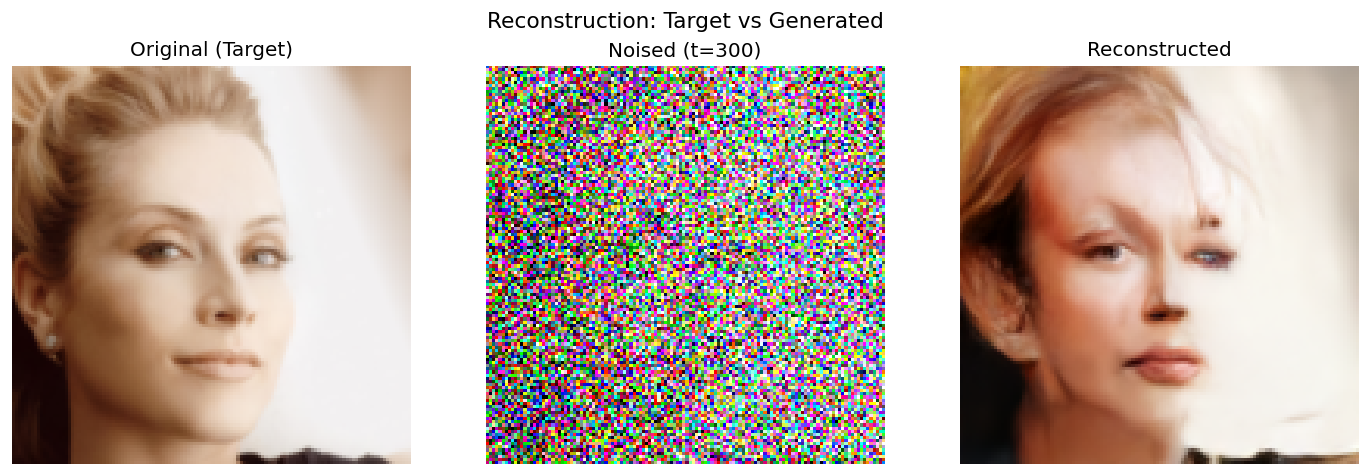


✨ NEW GENERATED IMAGES


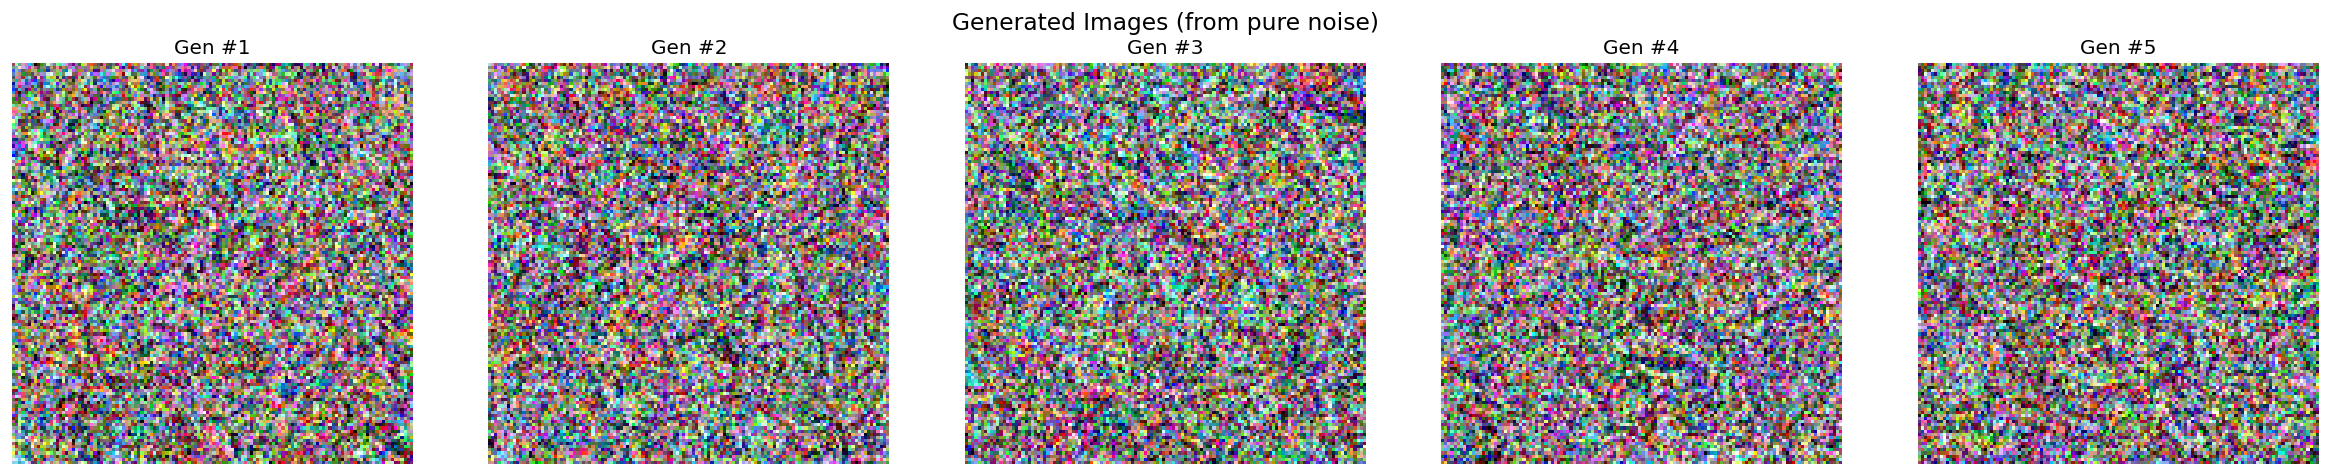


🔄 REVERSE DIFFUSION (DENOISING STEPS)


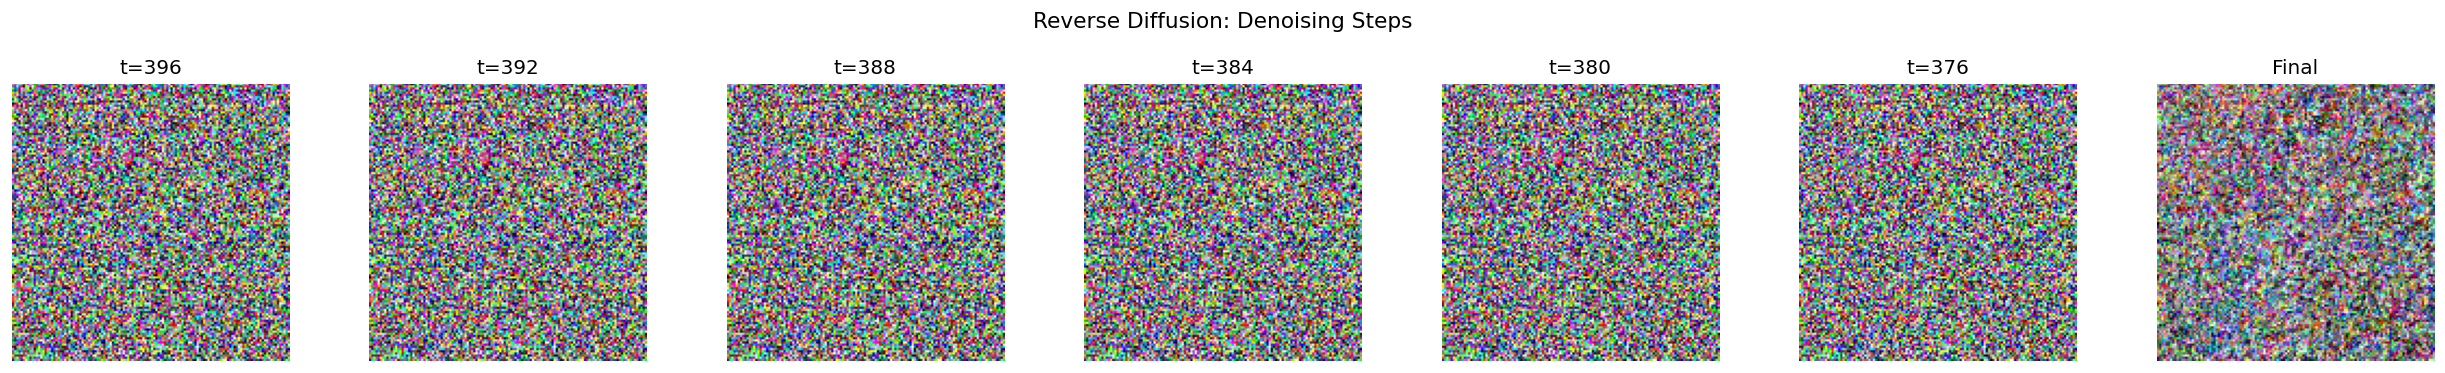

In [25]:
from IPython.display import Image, display
import os

save_dir = "/kaggle/working/ddpm_outputs"

print("TARGET RECONSTRUCTION")
reconstruction_path = os.path.join(save_dir, "reconstruction.png")
if os.path.exists(reconstruction_path):
    display(Image(filename=reconstruction_path))
else:
    print("reconstruction.png not found yet.")

print("\n✨ NEW GENERATED IMAGES")
generated_path = os.path.join(save_dir, "generated_images.png")
if os.path.exists(generated_path):
    display(Image(filename=generated_path))
else:
    print("generated_images.png not found yet.")
    
print("\nREVERSE DIFFUSION (DENOISING STEPS)")
reverse_path = os.path.join(save_dir, "reverse_diffusion_steps.png")
if os.path.exists(reverse_path):
    display(Image(filename=reverse_path))
else:
    print("reverse_diffusion_steps.png not found yet.")